# **Trabajo Grupo 10 – Aprendizaje Supervisado**

### **Integrantes**
* Tomás Contreras
* Carlos Duarte
* Renato Atencio

### **Avisos**
Tras conversar con el profesor Matthieu, se decidió **utilizar el dataset correspondiente al Grupo 1**, debido a que los datos del dataset originalmente asignado al Grupo 10 presentaban inconsistencias que podían afectar el análisis.

Durante el desarrollo de este trabajo se utilizaron herramientas complementarias como ChatGPT, con los siguientes fines:
- Mejorar la **redacción** de las respuestas y **corregir** errores ortográficos.
- Apoyar en la **creación de gráficos** representativos para el análisis de los datos.

### **Objetivo**
El objetivo de este trabajo es aplicar técnicas de aprendizaje supervisado utilizando como variables predictoras las primeras cuatro columnas del dataset (`pm25`, `no2`, `trafico`, `viento`). En particular, se busca:

1. **Problema de clasificación:**
   Determinar si existe o no una condición de alerta.
2. **Problema de regresión:**
   Predecir los valores de contaminación.
3. **Evaluación crítica:**
   Analizar y evaluar la metodología empleada, así como la calidad de los resultados obtenidos, identificando posibles mejoras y limitaciones del enfoque utilizado.

### **Imports y Carga de datos** 

In [235]:
import matplotlib.pyplot as plt
import pandas as pd
import sklearn
import numpy as np
import seaborn as sns

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_squared_error, mean_absolute_error, r2_score
from sklearn.tree import DecisionTreeRegressor

In [6]:
ruta = Path("data/Grupo1.csv")
if not ruta.exists():
    ruta = Path("P3/Grupo1.csv")

df_raw = pd.read_csv(ruta, sep=";")

col_analisis = ["pm25", "no2", "trafico", "viento"]
col_clasificacion = "alerta"
col_regresion = "contaminacion"

### **Limpieza**

pm25       5
no2        5
trafico    5
viento     5
dtype: int64
pm25       0
no2        0
trafico    0
viento     0
dtype: int64


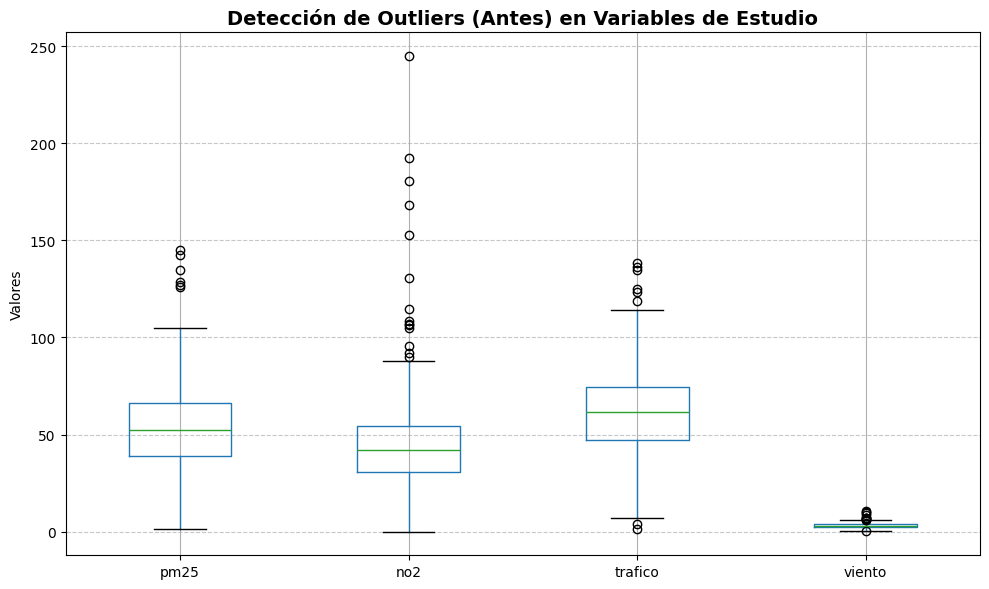

             pm25         no2     trafico      viento  contaminacion
count  458.000000  458.000000  458.000000  458.000000     458.000000
mean    53.810131   44.344127   61.785699    3.261397     141.645000
std     22.465846   24.349825   22.751395    1.277314      40.236008
min      1.310000    0.060000    1.440000    0.320000      38.980000
25%     39.057500   30.570000   47.147500    2.530000     116.982500
50%     52.125000   42.015000   61.380000    3.105000     138.980000
75%     66.355000   54.150000   74.652500    3.930000     164.215000
max    144.910000  244.840000  138.100000   10.530000     293.850000


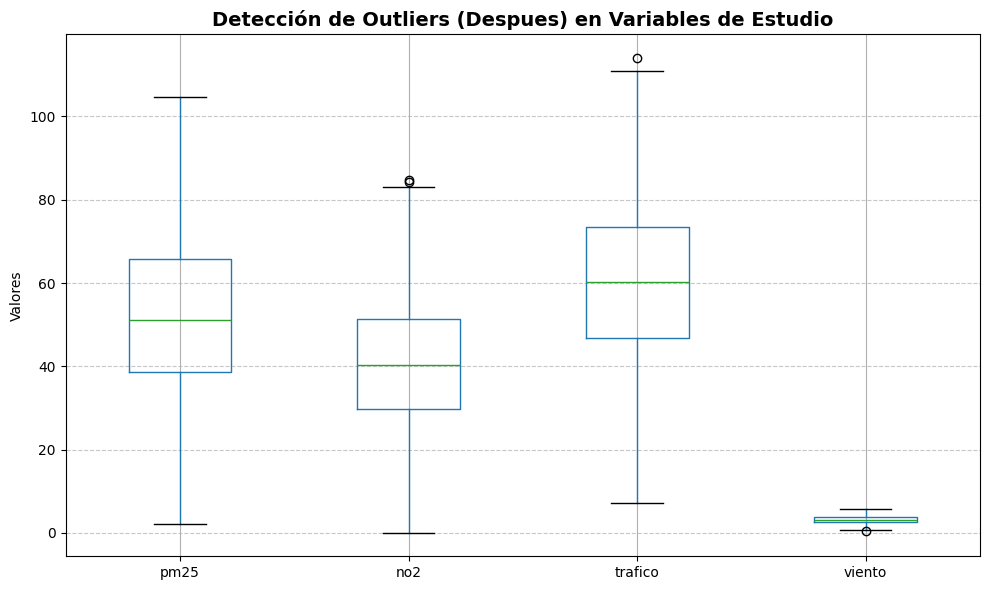

             pm25         no2     trafico      viento  contaminacion
count  429.000000  429.000000  429.000000  429.000000      429.00000
mean    52.446340   40.967319   60.244033    3.141772      138.10711
std     20.189647   16.502287   20.709577    1.012826       35.76671
min      2.180000    0.060000    7.230000    0.520000       38.98000
25%     38.710000   29.640000   46.890000    2.520000      115.93000
50%     51.160000   40.310000   60.330000    3.090000      137.94000
75%     65.670000   51.430000   73.350000    3.840000      160.87000
max    104.720000   84.770000  114.030000    5.780000      261.51000


In [123]:
# Check para ver si hay valores nulos
print(df_raw[col_analisis].isnull().sum())

# Nulos
df_clean = df_raw.dropna()

# Negativos
df_clean = df_clean.loc[
    (df_clean["no2"] > 0) &
    (df_clean["pm25"] > 0) &
    (df_clean["trafico"] > 0) &
    (df_clean["viento"] > 0) &
    (df_clean["contaminacion"] > 0)
]

# Check para ver si hay valores nulos
print(df_clean[col_analisis].isnull().sum())

# Outliers
# Vista de outliers
plt.figure(figsize=(10, 6))
df_clean[col_analisis].boxplot()
plt.title("Detección de Outliers (Antes) en Variables de Estudio", fontsize=14, fontweight="bold")
plt.ylabel("Valores")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("eda_outliers_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

print(df_clean.describe())

## Metodo de limpieza basado en IQR
for col in col_analisis:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    df_clean = df_clean[(df_clean[col] >= limite_inferior) & (df_clean[col] <= limite_superior)]

# Grafico sin los outliers
plt.figure(figsize=(10, 6))
df_clean[col_analisis].boxplot()
plt.title("Detección de Outliers (Despues) en Variables de Estudio", fontsize=14, fontweight="bold")
plt.ylabel("Valores")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("eda_outliers_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

print(df_clean.describe())

## **Problema de clasificacion**

In [124]:
# Convertimos la variable de clasificacion a 0/1.
df_clean[col_clasificacion] = df_clean[col_clasificacion].map({
    True: 1,
    False: 0,
    "True": 1,
    "False": 0,
})

print("\nCantidad de ejemplos por clase:")
print(df_clean[col_clasificacion].value_counts(dropna=False))
# Este print nos indica que existe un desvalanceo en el dataframe, 
# no es critico pero se debe tener en cuenta


Cantidad de ejemplos por clase:
alerta
0    297
1    132
Name: count, dtype: int64


### **Resolución con regresión logistica**

In [125]:
def evaluar_clasificacion(nombre_modelo, y_real, y_pred):
    print(f"=== {nombre_modelo} ===")
    print(f"Accuracy: {accuracy_score(y_real, y_pred):.3f}")
    print("\nReporte de clasificacion:")
    print(classification_report(
        y_real,
        y_pred,
        target_names=["No alerta", "Alerta"],
        zero_division=0,
    ))

    matriz = confusion_matrix(y_real, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(
        matriz,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No alerta", "Alerta"],
        yticklabels=["No alerta", "Alerta"],
    )
    plt.title(f"Matriz de confusion - {nombre_modelo}")
    plt.xlabel("Prediccion")
    plt.ylabel("Valor real")
    plt.show()

In [188]:
X = df_clean[col_analisis]
y = df_clean[col_clasificacion].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (343, 4)
Test size: (86, 4)


=== Regresion Logistica ===
Accuracy: 0.953

Reporte de clasificacion:
              precision    recall  f1-score   support

   No alerta       0.97      0.97      0.97        60
      Alerta       0.92      0.92      0.92        26

    accuracy                           0.95        86
   macro avg       0.94      0.94      0.94        86
weighted avg       0.95      0.95      0.95        86



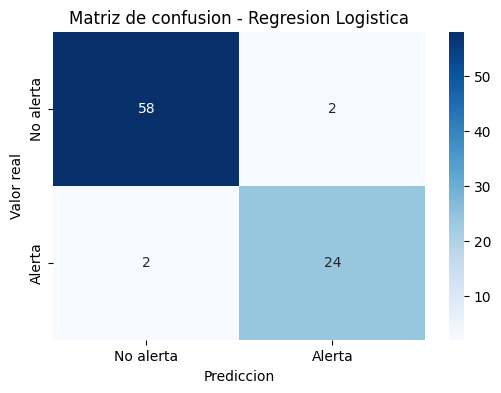

In [190]:
# Regresion Logistica
modelo_logistico = LogisticRegression(max_iter=100)
modelo_logistico.fit(X_train, y_train)

y_pred_logistico = modelo_logistico.predict(X_test)
evaluar_clasificacion("Regresion Logistica", y_test, y_pred_logistico)

=== Arbol de Decision ===
Accuracy: 0.884

Reporte de clasificacion:
              precision    recall  f1-score   support

   No alerta       0.89      0.95      0.92        60
      Alerta       0.86      0.73      0.79        26

    accuracy                           0.88        86
   macro avg       0.88      0.84      0.86        86
weighted avg       0.88      0.88      0.88        86



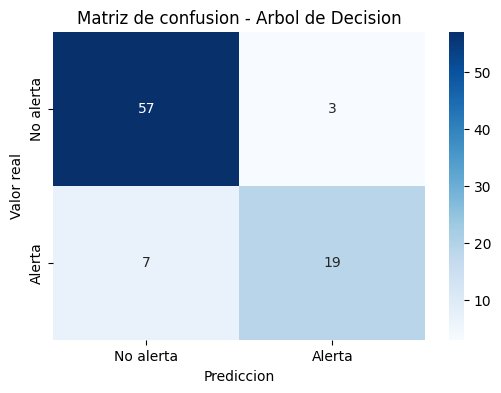

In [228]:
# Arbol de Decision
modelo_arbol_clasificacion = DecisionTreeClassifier(max_depth=4)
modelo_arbol_clasificacion.fit(X_train, y_train)

y_pred_arbol_clasificacion = modelo_arbol_clasificacion.predict(X_test)
evaluar_clasificacion("Arbol de Decision", y_test, y_pred_arbol_clasificacion)

## **Problema de regresión**

In [234]:
def evaluar_regresion(nombre_modelo, y_real, y_pred):
    mse = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_real, y_pred)
    r2 = r2_score(y_real, y_pred)

    print(f"=== {nombre_modelo} ===")
    print(f"MSE: {mse:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"MAE: {mae:.3f}")
    print(f"R2: {r2:.3f}")

In [233]:
X_reg = df_clean[col_analisis]
y_reg = df_clean[col_regresion]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
)

print("Train:", X_train_reg.shape)
print("Test:", X_test_reg.shape)

Train: (343, 4)
Test: (86, 4)


In [236]:
# Modelo 1: Regresion Lineal.
modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train_reg, y_train_reg)

y_pred_lineal = modelo_lineal.predict(X_test_reg)
evaluar_regresion("Regresion Lineal", y_test_reg, y_pred_lineal)

print("\nIntercepto:", modelo_lineal.intercept_)
print("Coeficientes:")

for variable, coeficiente in zip(col_analisis, modelo_lineal.coef_):
    print(f"{variable}: {coeficiente:.3f}")

=== Regresion Lineal ===
MSE: 447.853
RMSE: 21.163
MAE: 16.582
R2: 0.702

Intercepto: 23.124620230117316
Coeficientes:
pm25: 0.754
no2: 0.859
trafico: 0.920
viento: -4.769


In [237]:
# Arbol de Decision para Regresion.
modelo_arbol_regresion = DecisionTreeRegressor(max_depth=4)
modelo_arbol_regresion.fit(X_train_reg, y_train_reg)

y_pred_arbol_regresion = modelo_arbol_regresion.predict(X_test_reg)
evaluar_regresion("Arbol de Decision para Regresion", y_test_reg, y_pred_arbol_regresion)

=== Arbol de Decision para Regresion ===
MSE: 851.610
RMSE: 29.182
MAE: 23.307
R2: 0.433


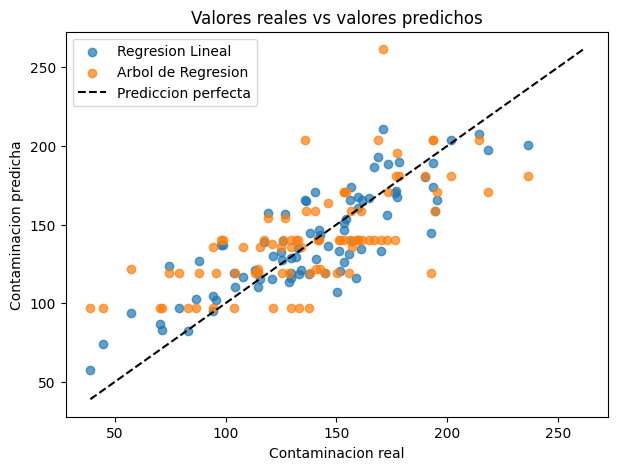

In [238]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test_reg, y_pred_lineal, alpha=0.7, label="Regresion Lineal")
plt.scatter(y_test_reg, y_pred_arbol_regresion, alpha=0.7, label="Arbol de Regresion")

minimo = min(y_test_reg.min(), y_pred_lineal.min(), y_pred_arbol_regresion.min())
maximo = max(y_test_reg.max(), y_pred_lineal.max(), y_pred_arbol_regresion.max())
plt.plot([minimo, maximo], [minimo, maximo], "k--", label="Prediccion perfecta")

plt.title("Valores reales vs valores predichos")
plt.xlabel("Contaminacion real")
plt.ylabel("Contaminacion predicha")
plt.legend()
plt.show()

In [239]:
resultados_regresion = pd.DataFrame({
    "real": y_test_reg,
    "pred_lineal": y_pred_lineal,
    "pred_arbol": y_pred_arbol_regresion,
})

resultados_regresion.head(10)

,real,pred_lineal,pred_arbol
294,171.24,210.776101,261.510000
257,142.40,143.381941,121.949118
98,125.77,139.560645,140.262329
435,78.98,97.092808,119.179818
238,201.55,204.055817,180.910000
147,178.26,189.533105,180.910000
295,74.36,123.812322,119.179818
120,98.90,137.144905,140.262329
109,70.25,87.103945,96.880952
115,153.36,150.805557,140.262329
